In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
import pandas as pd

input_file_path_new = "D:\\final_year_project\\final_export\\csv\\new\\training_parameters_postprocessing_new.csv"
df = pd.read_csv(input_file_path_new)

# Define features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1].values.reshape(-1, 1)   # The last column

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).flatten()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Define and train Lasso regression model
model_l1 = Lasso(alpha=0.1)  # You can tune alpha
model_l1.fit(X_train, y_train)

# Predict
y_pred_l1 = model_l1.predict(X_test)

# Coefficients
print("L1 Coefficients:", model_l1.coef_)
print("L1 Intercept:", model_l1.intercept_)

# Define and train Ridge regression model
model_l2 = Ridge(alpha=1.0)  # You can tune alpha
model_l2.fit(X_train, y_train)

# Predict
y_pred_l2 = model_l2.predict(X_test)

# Coefficients
print("L2 Coefficients:", model_l2.coef_)
print("L2 Intercept:", model_l2.intercept_)


L1 Coefficients: [ 0.          0.         -0.          0.          0.          0.
 -0.         -0.          0.         -0.         -0.          0.27560283
  0.17145959  0.          0.19463364 -0.53402184  0.          0.
  0.         -0.        ]
L1 Intercept: -0.01466059623059151
L2 Coefficients: [ 0.09813483  0.06338483 -0.07694979  0.00282196  0.12025028 -0.07752434
 -0.03767818 -0.07183638  0.09229716 -0.03763067 -0.02763758  0.38519298
  0.2474559  -0.02020772  0.24712607 -0.65028694 -0.03620378 -0.07581789
 -0.07096107 -0.0561268 ]
L2 Intercept: -0.018200319483294054


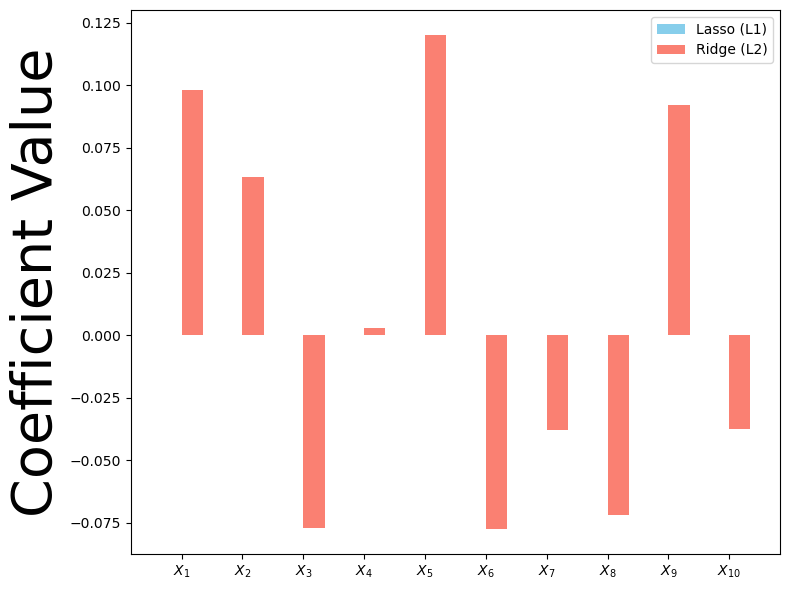

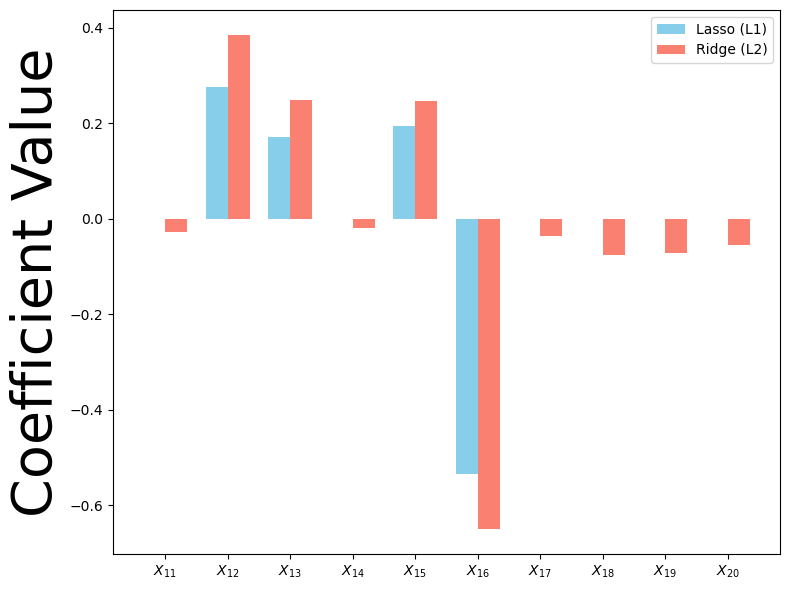

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Replace with your actual coefficients if loading from model
l1_coeffs = np.array([0., 0., -0., 0., 0., 0., -0., -0., 0., -0., -0., 0.27560283,
                      0.17145959, 0., 0.19463364, -0.53402184, 0., 0., 0., -0.])

l2_coeffs = np.array([0.09813483, 0.06338483, -0.07694979, 0.00282196, 0.12025028,
                      -0.07752434, -0.03767818, -0.07183638, 0.09229716, -0.03763067,
                      -0.02763758, 0.38519298, 0.2474559, -0.02020772, 0.24712607,
                      -0.65028694, -0.03620378, -0.07581789, -0.07096107, -0.0561268])

# LaTeX-style feature labels: x_1, x_2, ..., x_20
feature_labels_latex = [f'$X_{{{i+1}}}$' for i in range(20)]

bar_width = 0.35

# ----------- First Figure: Features 1–10 -----------
x1 = np.arange(10)
plt.figure(figsize=(8, 6))
plt.bar(x1 - bar_width/2, l1_coeffs[:10], width=bar_width, label='Lasso (L1)', color='skyblue')
plt.bar(x1 + bar_width/2, l2_coeffs[:10], width=bar_width, label='Ridge (L2)', color='salmon')
plt.xticks(x1, feature_labels_latex[:10])
plt.ylabel("Coefficient Value", fontsize=40)
plt.legend()
plt.tight_layout()
output_path1 = "D:\\final_year_project\\final_export\\pics_after_sim\\new_analysis\\l1_l2_coeff_part1.png"
plt.savefig(output_path1, dpi=800)
plt.show()

# ----------- Second Figure: Features 11–20 -----------
x2 = np.arange(10)
plt.figure(figsize=(8, 6))
plt.bar(x2 - bar_width/2, l1_coeffs[10:], width=bar_width, label='Lasso (L1)', color='skyblue')
plt.bar(x2 + bar_width/2, l2_coeffs[10:], width=bar_width, label='Ridge (L2)', color='salmon')
plt.xticks(x2, feature_labels_latex[10:])
plt.ylabel("Coefficient Value", fontsize=40)
plt.legend()
plt.tight_layout()
output_path2 = "D:\\final_year_project\\final_export\\pics_after_sim\\new_analysis\\l1_l2_coeff_part2.png"
plt.savefig(output_path2, dpi=800)
plt.show()
